In [582]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [583]:
data = pd.read_csv(r"Datasets\train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [584]:
newdata = data[['Age','Embarked','Survived']]
print(newdata.head())

    Age Embarked  Survived
0  22.0        S         0
1  38.0        C         1
2  26.0        S         1
3  35.0        S         1
4  35.0        S         0


In [585]:
mapping = {'S': 0, 'C': 1, 'Q': 2}
newdata['Embarked'] = newdata['Embarked'].map(mapping).fillna(0).astype(int)

In [586]:
newdata['Embarked'].value_counts()

Embarked
0    646
1    168
2     77
Name: count, dtype: int64

In [587]:
newdata.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Embarked  891 non-null    int64  
 2   Survived  891 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 21.0 KB


In [588]:
newdata.isnull().mean()

Age         0.198653
Embarked    0.000000
Survived    0.000000
dtype: float64

In [589]:
x = newdata.drop(columns=['Survived'])
y = newdata['Survived']
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
X_train.head()

,Age,Embarked
331,45.5,0
733,23.0,0
382,32.0,0
704,26.0,0
813,6.0,0


In [590]:
X_train.shape, X_test.shape

((712, 2), (179, 2))

In [591]:
X_train.isnull().mean()

Age         0.196629
Embarked    0.000000
dtype: float64

In [592]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_Embarked = X_train['Embarked'].mean()
median_Embarked = X_train['Embarked'].median()

In [593]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Embarked_median'] = X_train['Embarked'].fillna(median_Embarked)
X_train['Embarked_mean'] = X_train['Embarked'].fillna(mean_Embarked)

In [594]:
X_train.sample(10)

,Age,Embarked,Age_median,Age_mean,Embarked_median,Embarked_mean
671,31.0,0,31.0,31.000000,0,0
61,38.0,0,38.0,38.000000,0,0
788,1.0,0,1.0,1.000000,0,0
660,50.0,0,50.0,50.000000,0,0
598,NaN,1,28.0,29.498846,1,1
365,30.0,0,30.0,30.000000,0,0
263,40.0,0,40.0,40.000000,0,0
134,25.0,0,25.0,25.000000,0,0
595,36.0,0,36.0,36.000000,0,0
756,28.0,0,28.0,28.000000,0,0


In [595]:
print(X_train['Age'].var())
print(X_train['Age_median'].var())
print(X_train['Age_mean'].var())

210.2517072477435
169.20731007048155
168.85193366872227


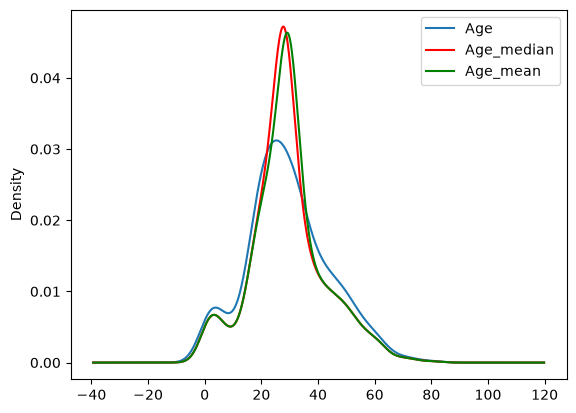

In [596]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind='kde', ax=ax)

X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [597]:
X_train.cov()

,Age,Embarked,Age_median,Age_mean,Embarked_median,Embarked_mean
Age,210.251707,-0.220521,210.251707,210.251707,-0.220521,-0.220521
Embarked,-0.220521,0.394789,-0.294784,-0.177099,0.394789,0.394789
Age_median,210.251707,-0.294784,169.207310,168.851934,-0.294784,-0.294784
Age_mean,210.251707,-0.177099,168.851934,168.851934,-0.177099,-0.177099
Embarked_median,-0.220521,0.394789,-0.294784,-0.177099,0.394789,0.394789
Embarked_mean,-0.220521,0.394789,-0.294784,-0.177099,0.394789,0.394789


In [598]:
X_train.corr()

,Age,Embarked,Age_median,Age_mean,Embarked_median,Embarked_mean
Age,1.000000,-0.029648,1.000000,1.000000,-0.029648,-0.029648
Embarked,-0.029648,1.000000,-0.036067,-0.021691,1.000000,1.000000
Age_median,1.000000,-0.036067,1.000000,0.998949,-0.036067,-0.036067
Age_mean,1.000000,-0.021691,0.998949,1.000000,-0.021691,-0.021691
Embarked_median,-0.029648,1.000000,-0.036067,-0.021691,1.000000,1.000000
Embarked_mean,-0.029648,1.000000,-0.036067,-0.021691,1.000000,1.000000


<Axes: >

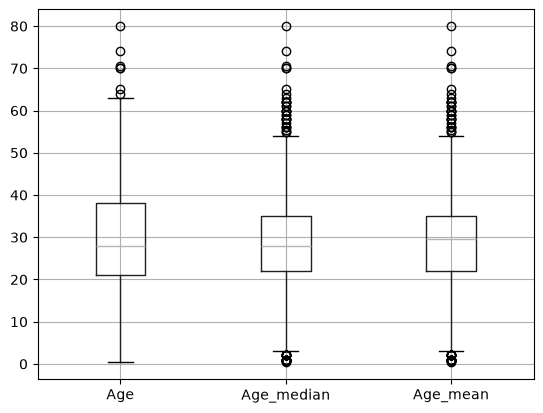

In [599]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

In [600]:
newdata

,Age,Embarked,Survived
0,22.0,0,0
1,38.0,1,1
2,26.0,0,1
3,35.0,0,1
4,35.0,0,0
...,...,...,...
886,27.0,0,0
887,19.0,0,1
888,NaN,0,0
889,26.0,1,1


In [601]:
newdata.isnull().sum()

Age         177
Embarked      0
Survived      0
dtype: int64

In [602]:
X_train,X_test,y_train,y_test = train_test_split(newdata.drop(columns='Survived'),newdata['Survived'],test_size=0.2,random_state=2)

In [603]:
X_train

,Age,Embarked
30,40.0,1
10,4.0,0
873,47.0,0
182,9.0,0
876,20.0,0
...,...,...
534,30.0,0
584,NaN,1
493,71.0,1
527,NaN,0


In [604]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [605]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Embarked'])
],remainder='passthrough')

In [606]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [607]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [608]:
trf.named_transformers_['imputer2'].statistics_

array([0.39325843])

In [609]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [610]:
X_train

array([[40.  ,  1.  ],
       [ 4.  ,  0.  ],
       [47.  ,  0.  ],
       ...,
       [71.  ,  1.  ],
       [28.75,  0.  ],
       [28.75,  0.  ]], shape=(712, 2))

arbitrary-value-imputation

In [611]:
newdata

,Age,Embarked,Survived
0,22.0,0,0
1,38.0,1,1
2,26.0,0,1
3,35.0,0,1
4,35.0,0,0
...,...,...,...
886,27.0,0,0
887,19.0,0,1
888,NaN,0,0
889,26.0,1,1


In [612]:
newdata.isnull().mean()

Age         0.198653
Embarked    0.000000
Survived    0.000000
dtype: float64

In [613]:
X_train,X_test,y_train,y_test = train_test_split(newdata.drop(columns="Survived"),newdata["Survived"],
test_size=0.2,random_state=42)

In [614]:
X_train.head()

,Age,Embarked
331,45.5,0
733,23.0,0
382,32.0,0
704,26.0,0
813,6.0,0


In [615]:
X_train["Age_99"] = X_train['Age'].fillna(99)
X_train["Age-minus1"] = X_train['Age'].fillna(-1)

In [616]:
X_train

,Age,Embarked,Age_99,Age-minus1
331,45.5,0,45.5,45.5
733,23.0,0,23.0,23.0
382,32.0,0,32.0,32.0
704,26.0,0,26.0,26.0
813,6.0,0,6.0,6.0
...,...,...,...,...
106,21.0,0,21.0,21.0
270,NaN,0,99.0,-1.0
860,41.0,0,41.0,41.0
435,14.0,0,14.0,14.0


In [617]:
print("Original",X_train['Age'].var())
print("Age -1 value",X_train['Age-minus1'].var())
print("Age99 value",X_train['Age_99'].var())

Original 210.2517072477435
Age -1 value 315.9955036260055
Age99 value 932.9665366701432


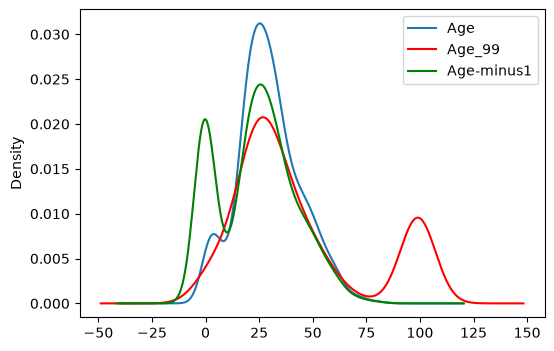

In [618]:
fig = plt.figure(figsize=(6, 4)) 
ax = fig.add_subplot(111)

X_train["Age"].plot(kind='kde', ax=ax)
X_train['Age_99'].plot(kind='kde', ax=ax, color='red')
X_train['Age-minus1'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

Using Sk-learn

In [619]:
X_train,X_test,y_train,y_test = train_test_split(newdata.drop(columns="Survived"),newdata["Survived"],
test_size=0.2,random_state=42)

In [620]:
imp = SimpleImputer(strategy='constant', fill_value=100)

trf = ColumnTransformer([
    ("imp_age", imp, ["Age"])  
], remainder="passthrough")

In [621]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imp_age', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

In [622]:
trf.named_transformers_['imp_age'].statistics_

array([100], dtype=object)

In [623]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [624]:
X_train

array([[45.5,  0. ],
       [23. ,  0. ],
       [32. ,  0. ],
       ...,
       [41. ,  0. ],
       [14. ,  0. ],
       [21. ,  0. ]], shape=(712, 2))

In [625]:
data = pd.DataFrame(X_train)
data.sample(5)

,0,1
559,13.0,1.0
36,2.0,0.0
123,19.0,0.0
297,70.0,0.0
232,100.0,0.0
